# TWO-STAGE MODEL 

In [1]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import mlflow
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from imblearn.over_sampling import SMOTE
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
import  pickle
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression


df = pd.read_csv("./ElectronicsProductsPricingData.csv", encoding='latin1')



df["prices.dateSeen"] = pd.to_datetime(df["prices.dateSeen"], errors='coerce')


# compute a percent‑discount column from the price fields
# y = ((regular_price - sale_price) / regular_price) * 100
# assume amountMax is the non‑sale price and amountMin the current price;
# guard against division by zero.

df['y'] = np.where(
    df['prices.amountMax'] > 0,
    100 * (df['prices.amountMax'] - df['prices.amountMin']) / df['prices.amountMax'],
    0
)
mlflow.end_run()
df = df.rename(columns={"prices.dateSeen": "date", "y": "y"})
df[["y","prices.amountMax","date","prices.amountMin"]].head()
mlflow.set_tracking_uri("http://86.50.20.250/")



/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/st/r78_rxtx0hd_yr_r8qtl08_c0000gn/T/ipykernel_85838/1992715493.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["prices.dateSeen"] = pd.to_datetime(df["prices.dateSeen"], errors='coerce')


In [2]:
from scripts.cleaning_categories import clean_and_map_categories

# ---- 4. Apply to dataframe ----
df["clean_categories"] = df["categories"].apply(clean_and_map_categories)

# ---- 5. Create MAIN main_main_category (for plotting) ----
def get_main_category(cat_list):
    return cat_list[0] if len(cat_list) > 0 else "unknown"

df["main_category"] = df["clean_categories"].apply(get_main_category)

# ---- 6. Optional: string version (good for plotting labels) ----
df["clean_categories_str"] = df["clean_categories"].apply(lambda x: " | ".join(x))

## Featureing enginnering 

In [3]:
df_2018 = df[df["date"].dt.year == 2018]
df = df[df["date"].dt.year == 2017]

train = df
test = df_2018


In [4]:
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)

df_2018['day_of_week'] = df_2018['date'].dt.dayofweek
df_2018['month'] = df_2018['date'].dt.month
df_2018['week_of_year'] = df_2018['date'].dt.isocalendar().week.astype(int)


# Binary flag for Thursday updates
df['is_thursday'] = (df['day_of_week'] == 3).astype(int)
df_2018['is_thursday'] = (df_2018['day_of_week'] == 3).astype(int)

### Our seasonality chart showed Q4  = hilday dicsount spike in 2017 

df["quater"] = df["month"].apply(lambda x: (x-1)//3 + 1)
df_2018["quater"] = df_2018["month"].apply(lambda x: (x-1)//3 + 1)


df["price_tier"] = pd.cut(df["prices.amountMin"], bins=[0, 50, 100, 200, np.inf], labels=['Low', 'Medium', 'High', 'Premium'])
df_2018["price_tier"] = pd.cut(df_2018["prices.amountMin"], bins=[0, 50, 100, 200, np.inf], labels=['Low', 'Medium', 'High', 'Premium'])



# Preview the engineered features
df[['date', 'day_of_week', 'week_of_year', 'is_thursday']].head()

,date,day_of_week,week_of_year,is_thursday
1,2017-12-14 06:00:00+00:00,3,50,1
2,2017-09-08 05:00:00+00:00,4,36,0
3,2017-10-10 05:00:00+00:00,1,41,0
4,2017-08-28 07:00:00+00:00,0,35,0
5,2017-10-24 04:00:00+00:00,1,43,0


Text(619.9949494949494, 0.5, 'Count')

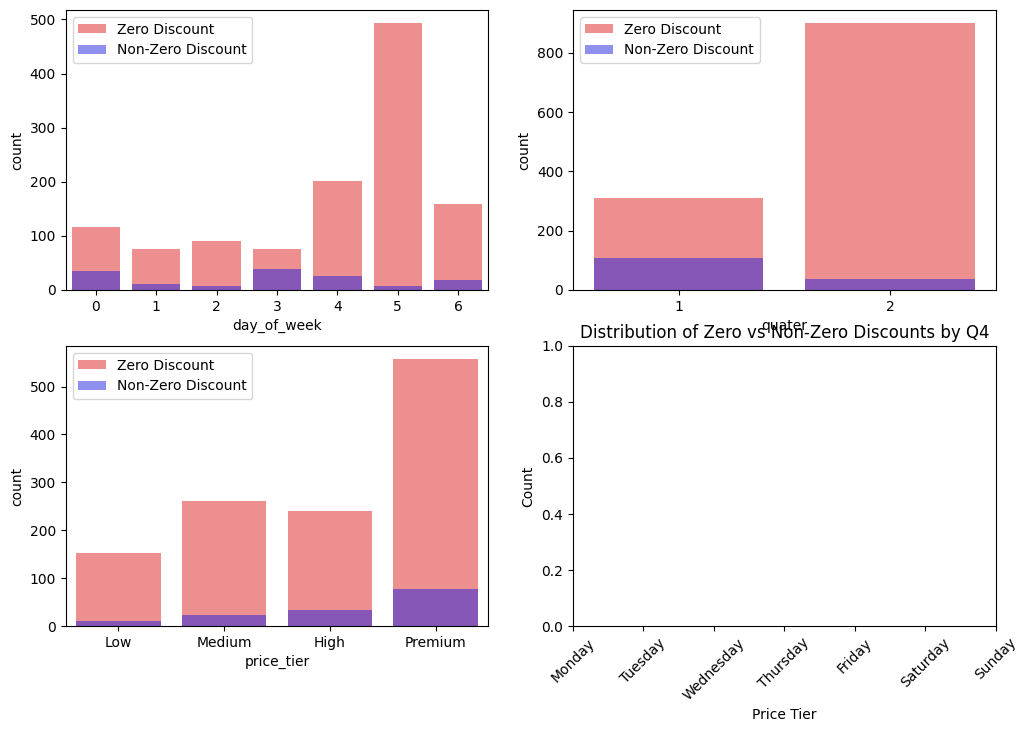

In [5]:
zero_count = test[test["y"] == 0]
non_zero_count =  test[test["y"] > 0]

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 8)   # ← control width here
)

weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x=zero_count["day_of_week"] ,color='red', alpha=0.5, label='Zero Discount', ax=axes[0, 0])
sns.countplot(x=non_zero_count["day_of_week"], color='blue', alpha=0.5, label='Non-Zero Discount', ax=axes[0, 0])
plt.xticks(ticks=range(7), labels=weekdays, rotation=45)
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.title('Distribution of Zero vs Non-Zero Discounts by Day of Week')
plt.savefig('./images/day_of_week.png')




sns.countplot(x=zero_count["quater"] ,color='red', alpha=0.5, label='Zero Discount', ax=axes[0, 1])
sns.countplot(x=non_zero_count["quater"], color='blue', alpha=0.5, label='Non-Zero Discount', ax=axes[0, 1])

plt.xlabel('Is Q4')
plt.ylabel('Count')
plt.title('Distribution of Zero vs Non-Zero Discounts by Q4')
plt.savefig('./images/q4.png')

sns.countplot(x=zero_count["price_tier"] ,color='red', alpha=0.5, label='Zero Discount', ax=axes[1, 0])
sns.countplot(x=non_zero_count["price_tier"], color='blue', alpha=0.5, label='Non-Zero Discount', ax=axes[1, 0])
plt.xlabel('Price Tier')
plt.ylabel('Count')


In [6]:
train_orig = train.copy()
test_orig  = test.copy()

# ── Binary flag: 1 = non-zero, 0 = zero ──
train_orig["is_nonzero"] = (train_orig["y"] > 0).astype(int)
test_orig["is_nonzero"]  = (test_orig["y"]  > 0).astype(int)

print("Train zero %    :", (train_orig["is_nonzero"] == 0).sum() / len(train_orig) * 100)
print("Test  zero %    :", (test_orig["is_nonzero"]  == 0).sum() / len(test_orig)  * 100)
print("Non-zero count  :", train_orig["is_nonzero"].sum())

Train zero %    : 87.06666666666666
Test  zero %    : 89.43870014771049
Non-zero count  : 291


In [7]:
train_copy = test_orig[test_orig["is_nonzero"] == 1].copy() 
train_copy = train_copy.groupby("main_category").count().sort_values(by="main_category", ascending=False)
train_copy.head(5)



,id,prices.amountMax,prices.amountMin,prices.availability,prices.condition,prices.currency,date,prices.isSale,prices.merchant,prices.shipping,...,y,clean_categories,clean_categories_str,day_of_week,month,week_of_year,is_thursday,quater,price_tier,is_nonzero
main_category,,,,,,,,,,,,,,,,,,,,,
wireless,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
usedslr interchangeable lenses,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
usb-to-vga adapters,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
tv_video,49,49,49,49,49,49,49,49,49,49,...,49,49,49,49,49,49,49,49,49,49
storage,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


### STAGE 1 - Logistics Regressions
- 

In [8]:
def make_lag_features(series, lags=[1, 2, 3, 7, 14, 30]):
    df = pd.DataFrame({"y": series})
    for lag in lags:
        df[f"lag_{lag}"] = df["y"].shift(lag)
    df["rolling_mean_3"]  = df["y"].shift(1).rolling(3).mean()
    df["rolling_mean_7"]  = df["y"].shift(1).rolling(7).mean()
    df["rolling_mean_14"] = df["y"].shift(1).rolling(14).mean()

    # ---- TIME FEATURES ----
    
    

    # ---- CATEGORY FEATURES ----
    source = train_orig if len(series) == len(train_orig) else test_orig

    week_zero_rate = (train_orig.groupby("day_of_week")["y"].apply(lambda x: (x == 0).mean()))
    df["week_zero_rate"] = (source["day_of_week"].map(week_zero_rate).values[:len(df)])

    week_mean = train_orig.groupby("day_of_week")["y"].mean()
    df["week_mean_discount"] = (source["day_of_week"].map(week_mean).values[:len(df)])
    


    df["is_computer"] = source["main_category"].str.lower().isin(
                            ["computer", "computers", "computing"]
                        ).astype(int).values[:len(df)]

    cat_zero_rate = (train_orig.groupby("main_category")["y"]
                     .apply(lambda x: (x == 0).mean()))
    df["cat_zero_rate"] = (source["main_category"]
                           .map(cat_zero_rate)
                           .values[:len(df)])
    cat_mean = train_orig.groupby("main_category")["y"].mean()
    df["cat_mean_discount"] = (source["main_category"]
                                .map(cat_mean)
                                .values[:len(df)])

    

    

    

    return df.dropna()


# ── Rebuild features ──
train_binary = make_lag_features(train_orig["is_nonzero"])
test_binary  = make_lag_features(test_orig["is_nonzero"])


feature_cols = [c for c in train_binary.columns if c != "y"]

X_train_clf = train_binary[feature_cols]
y_train_clf = train_binary["y"]
X_test_clf  = test_binary[feature_cols]
y_test_clf  = test_binary["y"]

scaler = StandardScaler()
X_train_clf_sc = scaler.fit_transform(X_train_clf)
X_test_clf_sc  = scaler.transform(X_test_clf)


# ── Calculate actual class weight from data ──
zero_count    = (y_train_clf == 0).sum()
nonzero_count = (y_train_clf == 1).sum()
total         = len(y_train_clf)

# Natural weight — reflects true sparsity
weight_0 = 1.0
weight_1 = zero_count / nonzero_count   # e.g. if 90% zeros → weight_1 = 9

print(f"Zero count    : {zero_count}")
print(f"Non-zero count: {nonzero_count}")
print(f"Weight for 1  : {weight_1:.2f}")

clf = LogisticRegression(
    class_weight={0: weight_0, 1: weight_1 * 0.5},  # ✅ dampen the minority boost
    max_iter=1000,
    C=0.1          # ✅ stronger regularization — reduces over-prediction
)
clf.fit(X_train_clf_sc, y_train_clf)

zero_pred       = clf.predict(X_test_clf_sc)
zero_pred_proba = clf.predict_proba(X_test_clf_sc)[:, 1]

print(f"\nPredicted non-zero: {zero_pred.sum()} / {len(zero_pred)}")
print(f"Actual  non-zero  : {int(y_test_clf.sum())} / {len(y_test_clf)}")



Zero count    : 1930
Non-zero count: 290
Weight for 1  : 6.66

Predicted non-zero: 165 / 1294
Actual  non-zero  : 139 / 1294


In [9]:
import numpy as np
import pandas as pd

def make_exog_features(df, is_train=True):
    """
    Build exogenous features for SARIMAX.
    df must have: date index, 'main_category' column, 'y' column
    """
    exog = pd.DataFrame(index=df.index)

    # ── TIME FEATURES ──
    exog["is_thursday"] = (pd.to_datetime(df.index).dayofweek == 3).astype(int)
    exog["is_q4"]       = (pd.to_datetime(df.index).quarter   == 4).astype(int)
    exog["is_weekend"]  = (pd.to_datetime(df.index).dayofweek >= 5).astype(int)
    exog["month_sin"]   = np.sin(2 * np.pi * pd.to_datetime(df.index).month / 12)
    exog["month_cos"]   = np.cos(2 * np.pi * pd.to_datetime(df.index).month / 12)

    # ── main_category FLAGS ──
    exog["is_tv_video"] = df["main_category"].str.lower().isin(
                              ["tv", "video", "tv & video"]
                          ).astype(int)

    exog["is_computer"] = df["main_category"].str.lower().isin(
                              ["computer", "computers", "computing"]
                          ).astype(int)

    exog["is_accessory"] = df["main_category"].str.lower().isin(
                               ["accessories", "accessory"]
                           ).astype(int)

    # ── main_category STATS (always computed from train_orig to avoid leakage) ──
    cat_zero_rate      = (train_orig.groupby("main_category")["y"]
                          .apply(lambda x: (x == 0).mean()))

    cat_mean_discount  = train_orig.groupby("main_category")["y"].mean()

    

    cat_spike_rate     = (train_orig.groupby("main_category")["is_nonzero"]
                          .mean())

    cat_median         = train_orig.groupby("main_category")["y"].median()

    exog["cat_zero_rate"]      = df["main_category"].map(cat_zero_rate).fillna(0)
    exog["cat_mean_discount"]  = df["main_category"].map(cat_mean_discount).fillna(0)
    
    exog["cat_spike_rate"]     = df["main_category"].map(cat_spike_rate).fillna(0)
    exog["cat_median"]         = df["main_category"].map(cat_median).fillna(0)

    # ── SPIKE BOOST FEATURES ──
    # Rolling non-zero rate per main_category per month
    cat_month_spike = (train_orig
                       .assign(month=pd.to_datetime(train_orig.index).month)
                       .groupby(["main_category", "month"])["is_nonzero"]
                       .mean())

    months = pd.to_datetime(df.index).month
    exog["cat_month_spike"] = [
        cat_month_spike.get((cat, m), 0)
        for cat, m in zip(df["main_category"], months)
    ]

    # ── INTERACTION FEATURES ──
    exog["q4_tv_boost"]        = exog["is_q4"]       * exog["is_tv_video"]
    exog["thursday_spike_cat"] = exog["is_thursday"]  * exog["cat_spike_rate"]
    exog["q4_spike_cat"]       = exog["is_q4"]        * exog["cat_spike_rate"]
    exog["computer_penalty"]   = exog["is_computer"]  * exog["cat_zero_rate"]

    # ── LOG TRANSFORM main_category mean (matches log-transformed y) ──
    exog["cat_mean_log"]   = np.log1p(exog["cat_mean_discount"])
    exog["cat_median_log"] = np.log1p(exog["cat_median"])

    return exog.astype(float)

In [10]:
# Make sure is_nonzero exists


train_orig["is_nonzero"] = (train_orig["y"] > 0).astype(int)
test_orig["is_nonzero"]  = (test_orig["y"]  > 0).astype(int)

# ── Build exog ──
exog_train_full = make_exog_features(train_orig, is_train=True)
exog_test_full  = make_exog_features(test_orig,  is_train=False)

# ── Non-zero only for SARIMAX training ──
train_nonzero       = train_orig[train_orig["y"] > 0].copy()
train_nonzero["y_log"] = np.log1p(train_nonzero["y"])
exog_train_nonzero  = exog_train_full.loc[train_nonzero.index]

print("Exog train shape (non-zero only):", exog_train_nonzero.shape)
print("Exog test  shape                :", exog_test_full.shape)
print("\nExog columns:", list(exog_train_nonzero.columns))
print("\nPreview:")
print(exog_train_nonzero.head())

Exog train shape (non-zero only): (291, 19)
Exog test  shape                : (1354, 19)

Exog columns: ['is_thursday', 'is_q4', 'is_weekend', 'month_sin', 'month_cos', 'is_tv_video', 'is_computer', 'is_accessory', 'cat_zero_rate', 'cat_mean_discount', 'cat_spike_rate', 'cat_median', 'cat_month_spike', 'q4_tv_boost', 'thursday_spike_cat', 'q4_spike_cat', 'computer_penalty', 'cat_mean_log', 'cat_median_log']

Preview:
     is_thursday  is_q4  is_weekend  month_sin  month_cos  is_tv_video  \
1            1.0    0.0         0.0        0.5   0.866025          0.0   
114          1.0    0.0         0.0        0.5   0.866025          0.0   
116          1.0    0.0         0.0        0.5   0.866025          0.0   
118          1.0    0.0         0.0        0.5   0.866025          0.0   
125          1.0    0.0         0.0        0.5   0.866025          0.0   

     is_computer  is_accessory  cat_zero_rate  cat_mean_discount  \
1            0.0           0.0       0.853448           4.214681  

In [11]:
mlflow.end_run()
mlflow.set_experiment("SARIMAX_Category_Features")


# ── Fit best SARIMA on non-zero data ──
best_rmse_s   = float("inf")
best_aic_s    = float("inf")
best_sarima   = None
best_params_s = None
best_model = None
m = 12

for p in range(0, 3):
    for q in range(0, 3):
        for P in range(0, 2):
            for Q in range(0, 7):
                

                if p == 0 and q == 0 and P == 0 and Q == 0:
                    continue

                try:
                    model = SARIMAX(
                        train_nonzero["y_log"],
                        exog=exog_train_nonzero,
                        order=(p, 0, q),
                        seasonal_order=(P, 1, Q, m),
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    )
                    model_fit = model.fit(disp=False)
                    aic = model_fit.aic

                    if aic < best_aic_s:
                        best_aic_s    = aic
                        best_sarima   = model_fit
                        best_params_s = (p, 0, q, P, 1, Q, m)
                        best_model = model_fit
                except Exception as e:
                    continue

print(f"\n✅ Best SARIMA params : {best_params_s}")
print(f"   Best AIC          : {best_aic_s:.4f}")

/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/l


✅ Best SARIMA params : (0, 0, 1, 0, 1, 5, 12)
   Best AIC          : 420.0235


In [12]:
# ── SARIMA forecasts (log scale → reverse) ──
n_test = len(test_orig)

# ✅ Pass exog_test_full to forecast since model was trained with exog
sarima_forecast_log = best_sarima.forecast(
    steps = n_test,
    exog  = exog_test_full          # ✅ same columns as used in fit()
)

# ── Sanity check ──
print("Forecast log scale min/max:", sarima_forecast_log.min().round(4),
                                     sarima_forecast_log.max().round(4))
# should be small numbers like 0.0 to 8.0 — if > 20 something exploded

sarima_forecast = np.expm1(sarima_forecast_log)   # back to original scale

# ── Align lengths (lag features drop some rows) ──
offset         = n_test - len(zero_pred)
sarima_aligned = sarima_forecast.values[offset:]
actual_aligned = test_orig["y"].values[offset:]

# ── Combine: zero_pred gates the sarima value ──
# Method 1 — Hard gate (0 or full value)
final_forecast_hard = zero_pred * sarima_aligned

# Method 2 — Soft gate (scale by probability)
final_forecast_soft = zero_pred_proba * sarima_aligned

print("\nForecast preview:")
preview = pd.DataFrame({
    "Actual"     : actual_aligned[:10],
    "SARIMA"     : sarima_aligned[:10].round(4),
    "Zero_Pred"  : zero_pred[:10],
    "Final_Hard" : final_forecast_hard[:10].round(4),
    "Final_Soft" : final_forecast_soft[:10].round(4),
})
print(preview.to_string())

Forecast log scale min/max: 1.4783 4.2984

Forecast preview:
     Actual   SARIMA  Zero_Pred  Final_Hard  Final_Soft
0  11.39522  26.1962          1     26.1962     13.3076
1   0.00000  21.9993          0      0.0000      4.0772
2   7.47611  18.9320          0      0.0000      3.5088
3   0.00000  14.9914          0      0.0000      2.7784
4   0.00000  14.3675          0      0.0000      1.2555
5   0.00000  15.7982          0      0.0000      2.4165
6   0.00000  29.4049          0      0.0000     12.8401
7   0.00000  31.9430          1     31.9430     19.6032
8   0.00000  10.2151          1     10.2151      5.8612
9   0.00000  18.3864          0      0.0000      8.7503


/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/ayushghimire/Documents/GitHub/jupyter-lab-models/arima/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [13]:
def evaluate(actual, forecast, label):
    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae  = np.mean(np.abs(actual - forecast))
    # RMSE % relative to actual mean
    rmse_pct = (rmse / actual.mean()) * 100 if actual.mean() != 0 else float("inf")

    print(f"\n  [{label}]")
    print(f"    RMSE      : {rmse:.4f}")
    print(f"    MAE       : {mae:.4f}")
    print(f"    RMSE %    : {rmse_pct:.2f}%")
    return rmse

print("\n===== TWO-STAGE MODEL EVALUATION =====")
rmse_hard = evaluate(actual_aligned, final_forecast_hard, "Hard Gate (0 or value)")
rmse_soft = evaluate(actual_aligned, final_forecast_soft, "Soft Gate (prob × value)")
rmse_base = evaluate(actual_aligned, sarima_aligned,      "SARIMA alone (baseline)")

print(f"\n  Best method: {'Hard' if rmse_hard < rmse_soft else 'Soft'} gate")


===== TWO-STAGE MODEL EVALUATION =====

  [Hard Gate (0 or value)]
    RMSE      : 12.4725
    MAE       : 5.1080
    RMSE %    : 429.52%

  [Soft Gate (prob × value)]
    RMSE      : 11.0853
    MAE       : 7.7298
    RMSE %    : 381.75%

  [SARIMA alone (baseline)]
    RMSE      : 22.0330
    MAE       : 20.6465
    RMSE %    : 758.76%

  Best method: Soft gate


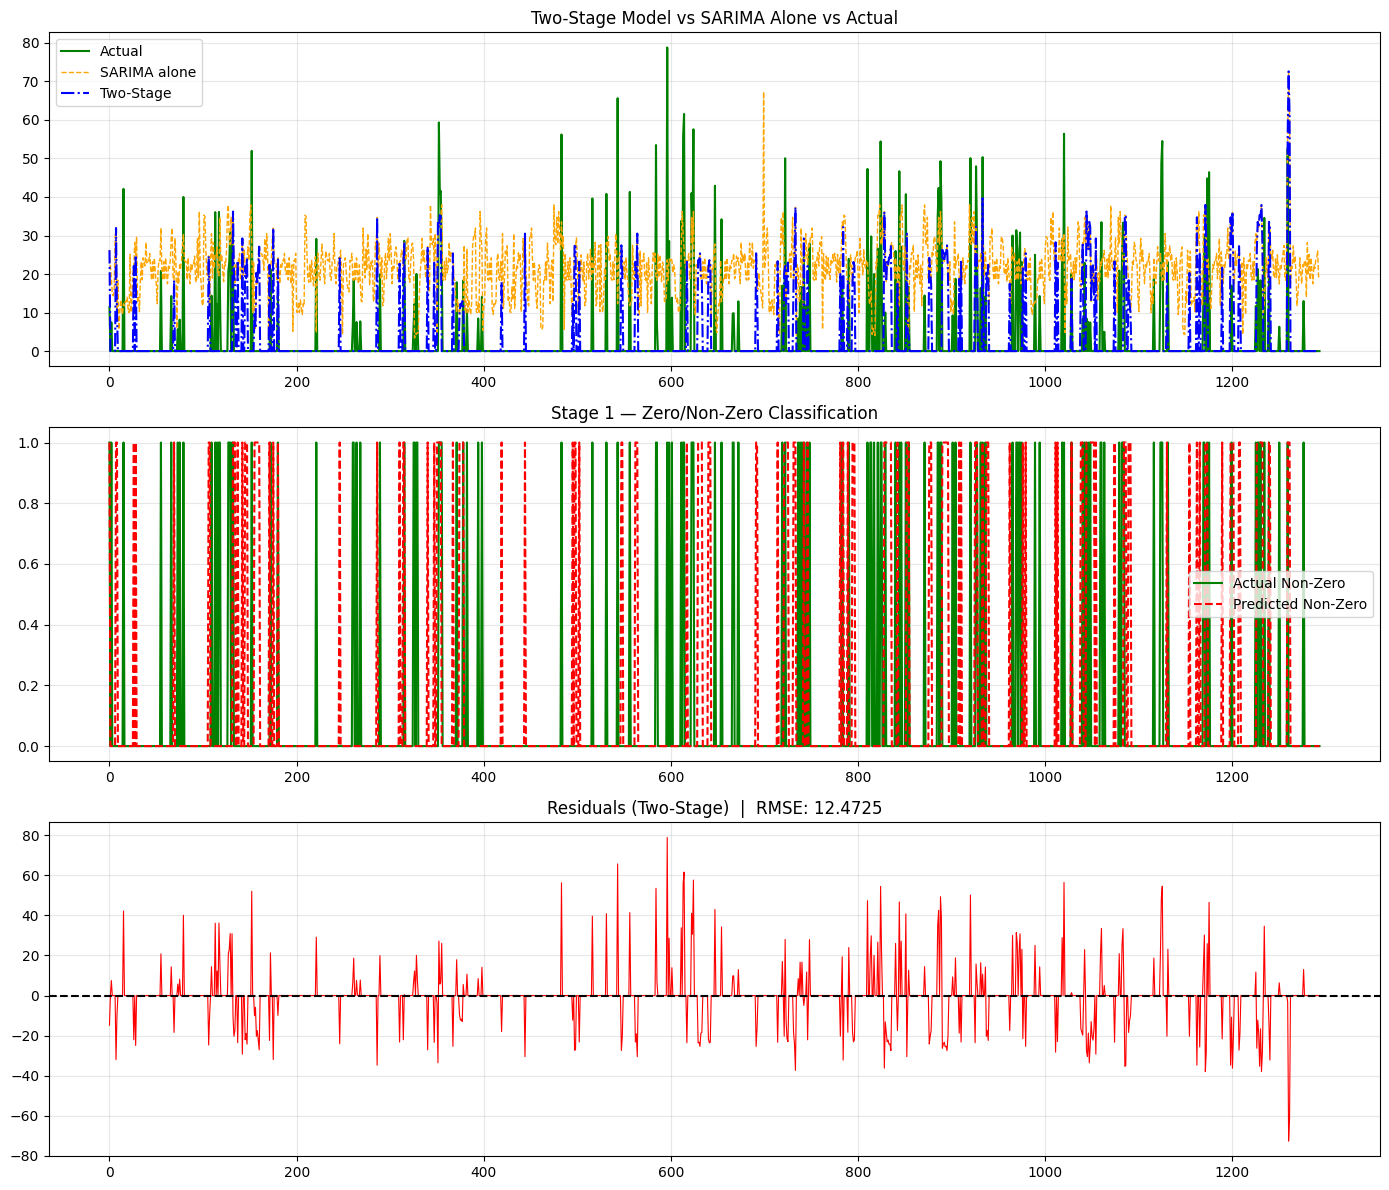

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# ── Plot 1: Full comparison ──
axes[0].plot(actual_aligned,        label="Actual",       color="green",  linewidth=1.5)
axes[0].plot(sarima_aligned,        label="SARIMA alone", color="orange", linewidth=1,  linestyle="--")
axes[0].plot(final_forecast_hard,   label="Two-Stage",    color="blue",   linewidth=1.5, linestyle="-.")
axes[0].set_title("Two-Stage Model vs SARIMA Alone vs Actual")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Plot 2: Zero prediction accuracy ──
axes[1].plot((actual_aligned > 0).astype(int), label="Actual Non-Zero",    color="green")
axes[1].plot(zero_pred,                         label="Predicted Non-Zero", color="red", linestyle="--")
axes[1].set_title("Stage 1 — Zero/Non-Zero Classification")
axes[1].legend()
axes[1].grid(alpha=0.3)

# ── Plot 3: Residuals ──
residuals = actual_aligned - final_forecast_hard
axes[2].plot(residuals, color="red", linewidth=0.8)
axes[2].axhline(0, color="black", linestyle="--")
axes[2].set_title(f"Residuals (Two-Stage)  |  RMSE: {rmse_hard:.4f}")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("./images/two_stage_forecast.png", dpi=150)
plt.show()


  TWO-STAGE MODEL PERFORMANCE REPORT
  RMSE (Two-Stage)         : 12.4725
  MSE  (Two-Stage)         : 155.5639
  MAE  (Two-Stage)         : 5.1080
  MAPE (Two-Stage)         : 96.80%
  F1   (Stage 1)           : 0.1836
  Precision (St.1)         : 0.1697
  Best Params              : (0, 0, 1, 0, 1, 5, 12)
  RMSE (SARIMA)            : 22.0330
  Improvement              : 43.4%
  Score                    : 4/11 checks passed

  [❌ FAIL]  RMSE % (vs non-zero mean)
           Value     : 46.47%
           Threshold : <= 20.0%
           ❌ RMSE % too high (46.5%) → try log transform or better features.

  [❌ FAIL]  Residual Mean (Bias)
           Value     : -0.2020
           Threshold : |mean| <= 0.05
           ❌ Bias detected (mean=-0.2020) → model consistently over/under-predicts.

  [✅ PASS]  Residual Skewness
           Value     : 0.8810
           Threshold : |skew| <= 1.1
           ✅ Residuals are not heavily skewed.

  [✅ PASS]  MAE % (vs non-zero mean)
           Value     : 

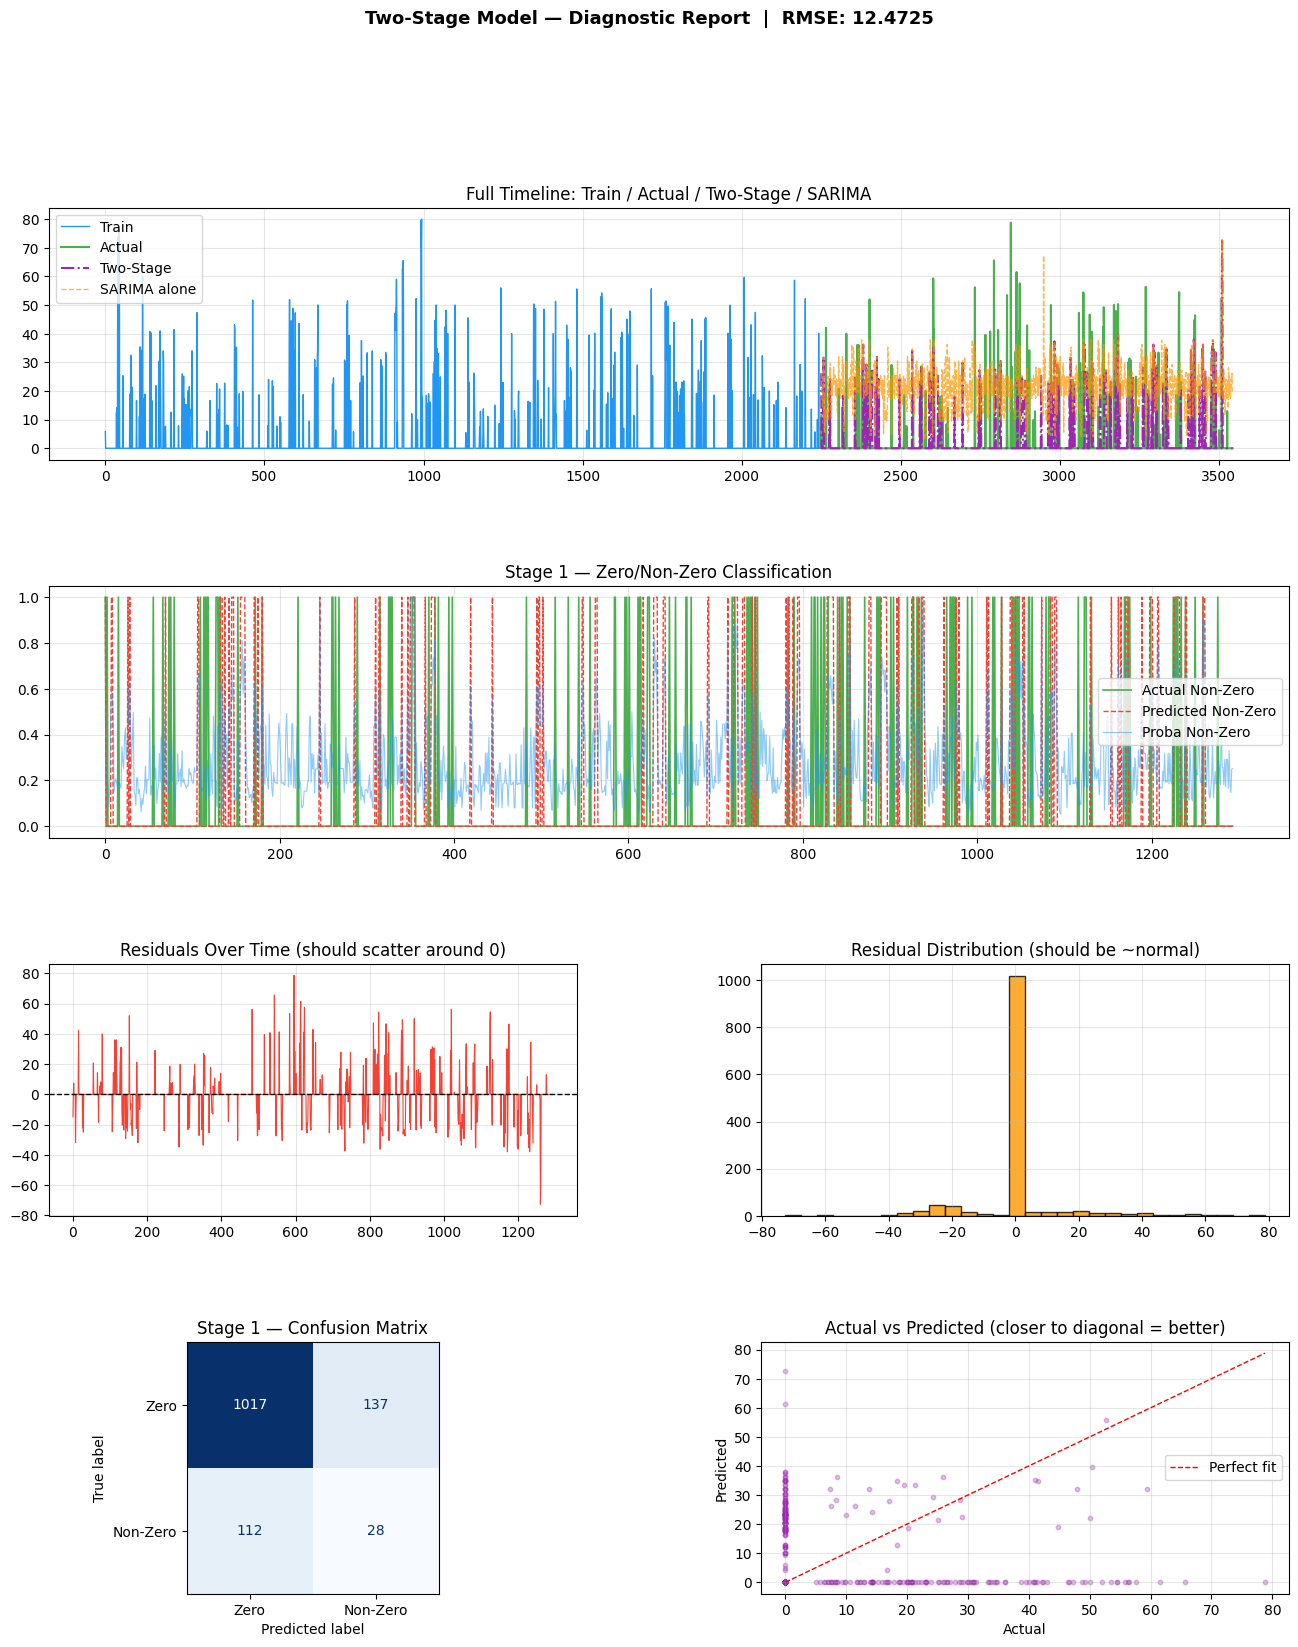

  📊 Saved: two_stage_diagnostics.png

  TWO-STAGE MODEL PERFORMANCE REPORT
  RMSE (Two-Stage)         : 11.0853
  MSE  (Two-Stage)         : 122.8845
  MAE  (Two-Stage)         : 7.7298
  MAPE (Two-Stage)         : 68.94%
  F1   (Stage 1)           : 0.1836
  Precision (St.1)         : 0.1697
  Best Params              : (0, 0, 1, 0, 1, 5, 12)
  RMSE (SARIMA)            : 22.0330
  Improvement              : 49.7%
  Score                    : 2/11 checks passed

  [❌ FAIL]  RMSE % (vs non-zero mean)
           Value     : 41.30%
           Threshold : <= 20.0%
           ❌ RMSE % too high (41.3%) → try log transform or better features.

  [❌ FAIL]  Residual Mean (Bias)
           Value     : -3.6298
           Threshold : |mean| <= 0.05
           ❌ Bias detected (mean=-3.6298) → model consistently over/under-predicts.

  [❌ FAIL]  Residual Skewness
           Value     : 2.5051
           Threshold : |skew| <= 1.1
           ❌ Skewed (2.51) → apply log1p or Box-Cox transform.

  [❌ FA

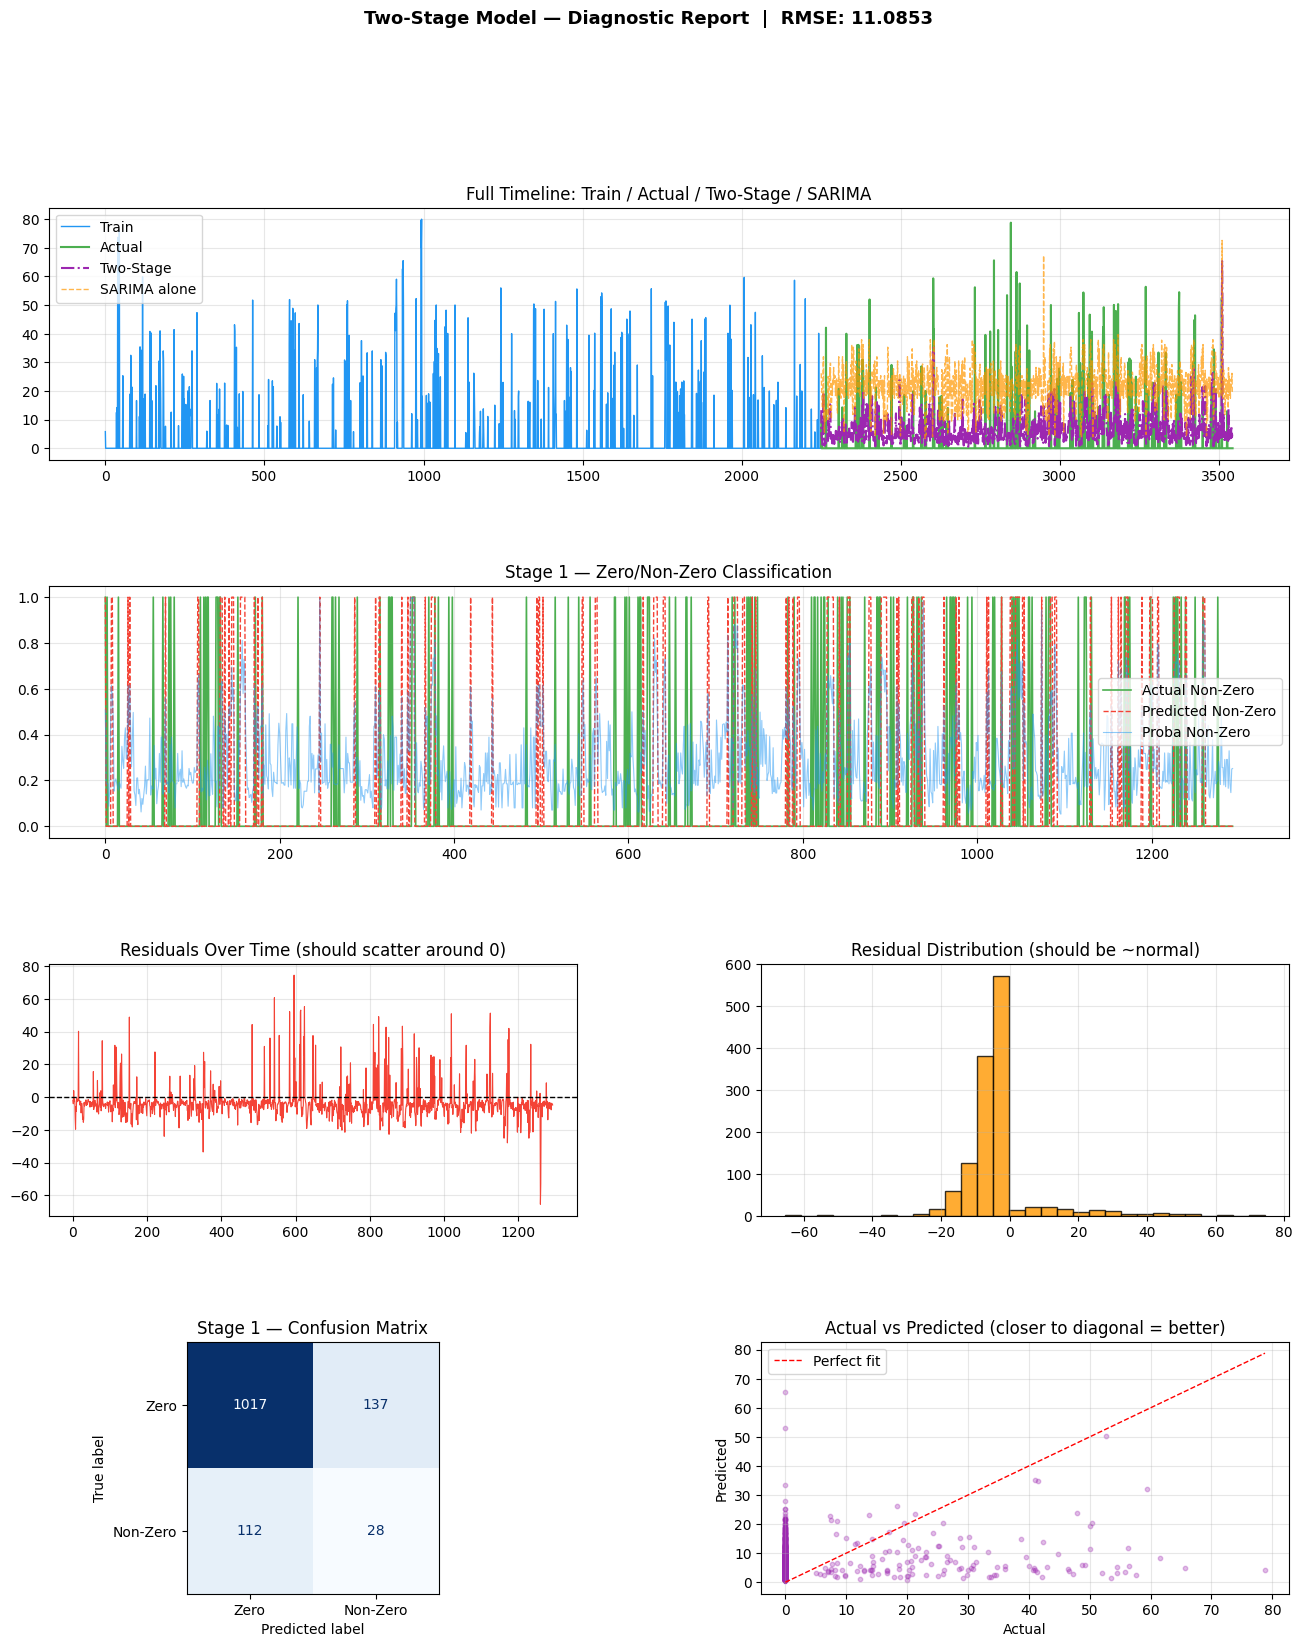

  📊 Saved: two_stage_diagnostics.png


[{'check': 'RMSE % (vs non-zero mean)',
  'value': '41.30%',
  'threshold': '<= 20.0%',
  'passed': np.False_,
  'advice': '❌ RMSE % too high (41.3%) → try log transform or better features.'},
 {'check': 'Residual Mean (Bias)',
  'value': '-3.6298',
  'threshold': '|mean| <= 0.05',
  'passed': np.False_,
  'advice': '❌ Bias detected (mean=-3.6298) → model consistently over/under-predicts.'},
 {'check': 'Residual Skewness',
  'value': '2.5051',
  'threshold': '|skew| <= 1.1',
  'passed': np.False_,
  'advice': '❌ Skewed (2.51) → apply log1p or Box-Cox transform.'},
 {'check': 'MAE % (vs non-zero mean)',
  'value': '7.7298  (28.8%)',
  'threshold': '<= 20.0%',
  'passed': np.False_,
  'advice': '❌ MAE too high (28.8%) → model misses average magnitude.'},
 {'check': 'MAPE (non-zero rows only)',
  'value': '68.94%',
  'threshold': '<= 50.0%',
  'passed': np.False_,
  'advice': '❌ MAPE too high (68.9%) → model struggles on non-zero predictions.'},
 {'check': 'Spike Capture (top 9% values)',

In [15]:
from scripts.testing import check_two_stage_performance

check_two_stage_performance(
    clf             = clf,
    regressor       = best_model,
    train           = train,
    test            = test,
    final_forecast  = final_forecast_hard,
    zero_pred       = zero_pred,
    zero_pred_proba = zero_pred_proba,
    sarima_forecast = sarima_aligned,
    best_params     = best_params_s
)

check_two_stage_performance(
    clf             = clf,
    regressor       = best_model,
    train           = train,
    test            = test,
    final_forecast  = final_forecast_soft,
    zero_pred       = zero_pred,
    zero_pred_proba = zero_pred_proba,
    sarima_forecast = sarima_aligned,
    best_params     = best_params_s
)


           MODEL COMPARISON
  Metric                             SARIMA    Two-Stage
  ---------------------------- ------------ ------------
  RMSE                              22.0330      12.4725
  MSE                              485.4537     155.5639
  MAE                               20.6465       5.1080
  MAPE                                69.6%        96.8%
  RMSE % (non-zero mean)              82.1%        46.5%

  Winner                       Two-Stage ✅
  RMSE Improvement                    43.4%



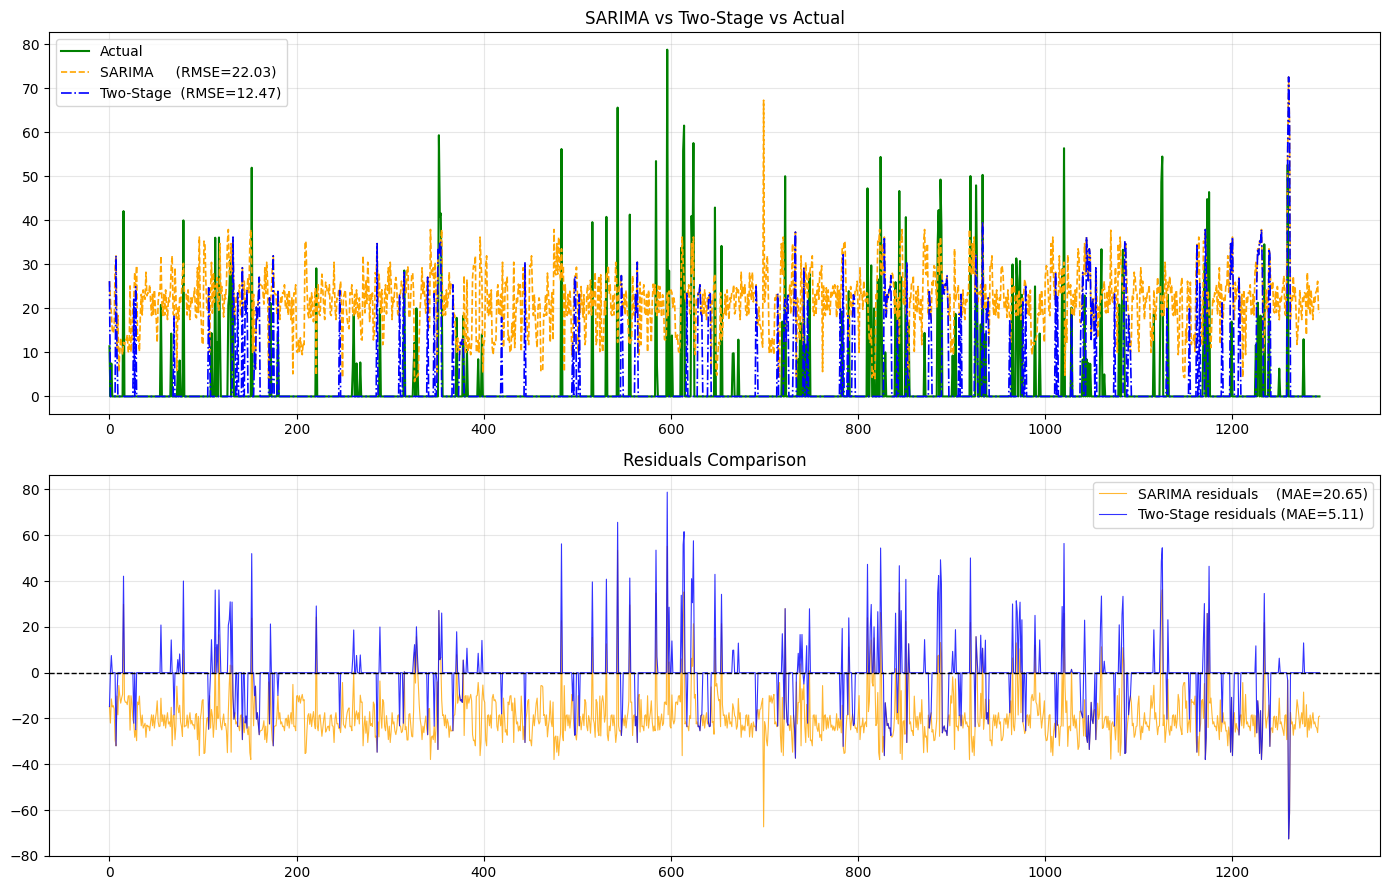

  📊 Saved: model_comparison.png
🏃 View run Model_Comparison at: http://86.50.20.250/#/experiments/11/runs/2623868b75744f09b23547400da0e7f7
🧪 View experiment at: http://86.50.20.250/#/experiments/11


{'sarima': {'rmse': np.float64(22.033013332537525),
  'mae': 20.64648676591801,
  'mse': 485.4536765117763,
  'mape': np.float64(69.60515796704648)},
 'two_stage': {'rmse': np.float64(12.47252624543547),
  'mae': 5.107958443744061,
  'mse': 155.5639109430766,
  'mape': np.float64(96.79683065499901)},
 'improvement_pct': np.float64(43.39164572184726)}

In [16]:
from scripts.testing import compare_models

compare_models(
    actual             = test["y"].values,
    sarima_forecast    = sarima_aligned,
    two_stage_forecast = final_forecast_hard
)